<a href="https://colab.research.google.com/github/mbrow210/MAT-422/blob/main/Section_3_2_Limits_Derivatives_Taylor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DynamicLLM/MAT422/blob/main/Skills/Student-Home-Work-Skills-Pack/mat422-section-3-2-limits-derivatives-taylor/assets/MAT422_Section_3_2_Limits_Derivatives_Taylor.ipynb)

# MAT 422 - Section 3.2: Limits, Derivatives, and Taylor's Theorem

**Topics:** Limits and continuity, Derivatives, Taylor's theorem

> Student note: This Colab badge is required for submission. Create or edit the notebook in Google Colab, then save it directly to GitHub so the badge/icon remains available for grading and reruns.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)


## Limits and continuity

*This section gives one compact Python demonstration of **Limits and continuity**. After running the code, add your own interpretation and change at least one input, parameter, or example so the notebook reflects your own work.*


---

A **limit** is the value that a function is heading toward as the input approaches a given point (important: limit is not what that specific point is, just the value it approaches)

**Continuity** is something a function can have if the value at the given point exists and is equal to the limit for that given point.

Limits can be taken from one or both sides of the function. If both limits (left and right) approach different values, this also disrupts the continuity.

---
### Given example

h values: [1.    0.5   0.1   0.01  0.001]
sin(h)/h: [0.841471 0.958851 0.998334 0.999983 1.      ]
These values approach 1 as h approaches 0.


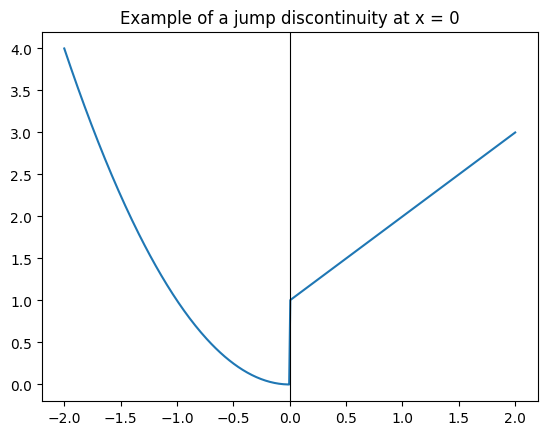

In [9]:
h = np.array([1, 0.5, 0.1, 0.01, 0.001])
values = np.sin(h) / h
print("h values:", h)
print("sin(h)/h:", values)
print("These values approach 1 as h approaches 0.")

x = np.linspace(-2, 2, 400)
y = np.where(x < 0, x**2, x + 1)
plt.plot(x, y)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Example of a jump discontinuity at x = 0")
plt.show()


---
### My example

Added function $\frac{e^h - 1}{h}$ as $h \to 0$. Limit is 1 from both sides

Added a piecewise function to show jump discontinuity
$f(x)=x^2$ for $x<0$ and $f(x)=x+1$ for $x \ge 0$. Left limit at 0 is 0 and right limit at 0 is 1. Shows how left and right limit can approach different values and how one limits value can end in an undefined value, while the other can be defined. This type of function is NOT continuous.

In [13]:
# (e^h - 1)/h from the right (h>0) and the left (-h)
right = (np.exp(h) - 1) / h
left = (np.exp(-h) - 1) / (-h)
print("\n(e^h - 1)/h  from right:", right)
print("(e^h - 1)/h  from left: ", left)

# check if both sides approach same number
if abs(right[-1] - 1) < 1e-3 and abs(left[-1] - 1) < 1e-3:
  print("\nBoth expressions approach 1 from both sides.")
else:
  print("\nExpressions don't approach 1 from both sides.")


(e^h - 1)/h  from right: [1.718282 1.297443 1.051709 1.005017 1.0005  ]
(e^h - 1)/h  from left:  [0.632121 0.786939 0.951626 0.995017 0.9995  ]

Both expressions approach 1 from both sides.


approaching 0 from left : [0.01     0.0001   0.000001 0.       0.      ]
approaching 0 from right: [1.1     1.01    1.001   1.0001  1.00001]
g(0) = 1.0

left limit ~ 0.00000, right limit ~ 1.00001
Two-sided limit exists?   False
Continuous at 0?          False


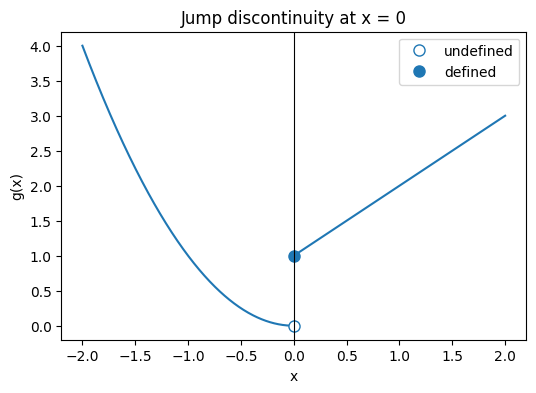

In [16]:
# left and right jump discontinuity
def g(x):
    return np.where(x < 0, x**2, x + 1)

eps = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5])
left_lim = g(-eps)      # approach 0 from the left
right_lim = g(eps)      # approach 0 from the right
g0 = g(np.array(0.0))   # actual value at 0

print("approaching 0 from left :", left_lim)
print("approaching 0 from right:", right_lim)
print("g(0) =", float(g0))

left_L, right_L = left_lim[-1], right_lim[-1]
print(f"\nleft limit ~ {left_L:.5f}, right limit ~ {right_L:.5f}")
print("Two-sided limit exists?  ", bool(np.isclose(left_L, right_L, atol=1e-3)))
print("Continuous at 0?         ", bool(np.isclose(left_L, right_L, atol=1e-3) and np.isclose(left_L, g0, atol=1e-3)))

x = np.linspace(-2, 2, 801)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x[x < 0], g(x[x < 0]), color="tab:blue")
ax.plot(x[x >= 0], g(x[x >= 0]), color="tab:blue")
ax.plot(0, 0, "o", mfc="white", mec="tab:blue", ms=8, label="undefined")
ax.plot(0, 1, "o", color="tab:blue", ms=8, label="defined")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Jump discontinuity at x = 0")
ax.set_xlabel("x"); ax.set_ylabel("g(x)")
ax.legend()
plt.show()

---

## Derivatives

*This section gives one compact Python demonstration of **Derivatives**. After running the code, add your own interpretation and change at least one input, parameter, or example so the notebook reflects your own work.*


---

A **derivative** is the instantaneous rate of change at a given point (i.e. slope of tangent line at given point).

Derivative can be found using the formula for the difference quotient:
$$f'(a)=\lim_{h\to 0}\frac{f(a+h)-f(a)}{h}.$$

Differences can be calculated using forward difference and central difference:
- **Forward difference:** $\dfrac{f(a+h)-f(a)}{h}$, with error of order $h$.
- **Central difference:** $\dfrac{f(a+h)-f(a-h)}{2h}$, with error of order $h^2$.


---
Given example

In [ ]:
def f(x):
    return x**3 - 2*x + 1

point = 1.5
steps = np.array([1e-1, 1e-2, 1e-3, 1e-4])
numeric_derivatives = (f(point + steps) - f(point - steps)) / (2 * steps)
exact_derivative = 3 * point**2 - 2

print("numeric derivative estimates:", numeric_derivatives)
print("exact derivative:", exact_derivative)
print("errors:", np.abs(numeric_derivatives - exact_derivative))


---
### My Example

Function used:
$f(x)=x^3-2x+1$

Derivative of function:
$f'(x)=3x^2-2$.


Function at $a=1.5$,
$f'(1.5)=3(2.25)-2=4.75$.


Step sizes are extended to $10^{-12}$ to show what happens if $h$ gets too small for floating-point.

In [17]:
def f(x):
    return x**3 - 2*x + 1

def f_prime(x):
    return 3*x**2 - 2

a = 1.5
steps = 10.0 ** -np.arange(1, 13)          # 1e-1, 1e-2, ..., 1e-12

forward = (f(a + steps) - f(a)) / steps
central = (f(a + steps) - f(a - steps)) / (2 * steps)
exact = f_prime(a)

err_fwd = np.abs(forward - exact)
err_cen = np.abs(central - exact)

print(f"exact f'({a}) = {exact}\n")
print(f"{'h':>8} {'forward':>12} {'central':>12} {'err fwd':>12} {'err cen':>12}")
for hh, fw, ce, ef, ec in zip(steps, forward, central, err_fwd, err_cen):
    print(f"{hh:8.0e} {fw:12.6f} {ce:12.6f} {ef:12.2e} {ec:12.2e}")

# Verification: for moderate h the errors follow the predicted orders
# (forward ~ h, so error/h ~ constant; central ~ h^2, so error/h^2 ~ constant)
print("\nforward err / h   (h=1e-1..1e-4):", err_fwd[:4] / steps[:4])
print("central err / h^2 (h=1e-1..1e-4):", err_cen[:4] / steps[:4]**2)
assert np.allclose(err_cen[:3] / steps[:3]**2, 1.0, rtol=1e-3)
print("Checks passed.")

exact f'(1.5) = 4.75

       h      forward      central      err fwd      err cen
   1e-01     5.210000     4.760000     4.60e-01     1.00e-02
   1e-02     4.795100     4.750100     4.51e-02     1.00e-04
   1e-03     4.754501     4.750001     4.50e-03     1.00e-06
   1e-04     4.750450     4.750000     4.50e-04     1.00e-08
   1e-05     4.750045     4.750000     4.50e-05     1.31e-10
   1e-06     4.750004     4.750000     4.50e-06     4.46e-10
   1e-07     4.750000     4.750000     4.51e-07     2.22e-09
   1e-08     4.750000     4.750000     3.77e-08     2.89e-08
   1e-09     4.750000     4.750000     3.93e-07     3.93e-07
   1e-10     4.750000     4.750000     3.93e-07     3.93e-07
   1e-11     4.749978     4.750000     2.18e-05     3.93e-07
   1e-12     4.750422     4.750422     4.22e-04     4.22e-04

forward err / h   (h=1e-1..1e-4): [4.6    4.51   4.501  4.5001]
central err / h^2 (h=1e-1..1e-4): [1.       1.       0.999999 1.000092]
Checks passed.


Meaning: For the function, the ratio (forward error)/h stays close to $3a=4.5$, which confirms first order accuracy, and central err /$h^2$ is a constant at 1 confirms second order accuracy. Central diff is more accurate for the same $h$.

Below shows a limit to this too: when $h$ gets too small then floating point round off dominates and the error increases more.

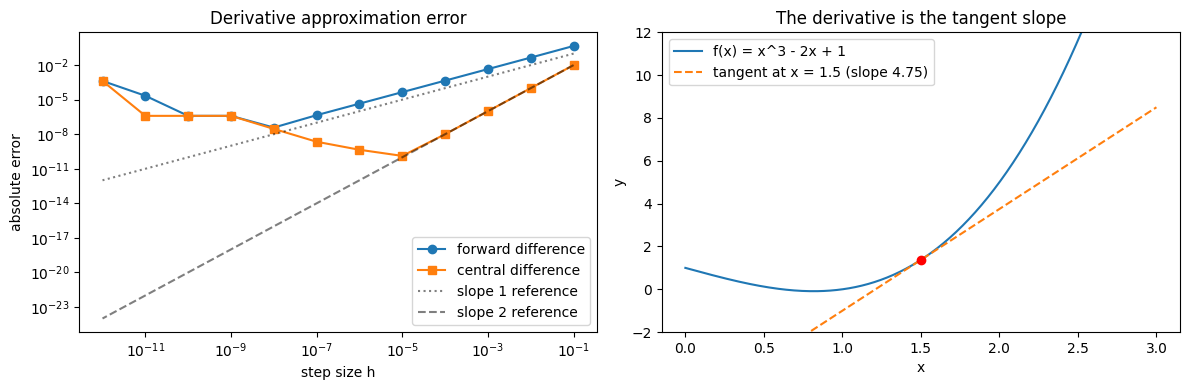

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: error vs step size (log-log)
axes[0].loglog(steps, err_fwd, "o-", label="forward difference")
axes[0].loglog(steps, err_cen, "s-", label="central difference")
axes[0].loglog(steps, steps, "k:", alpha=0.5, label="slope 1 reference")
axes[0].loglog(steps, steps**2, "k--", alpha=0.5, label="slope 2 reference")
axes[0].set_xlabel("step size h"); axes[0].set_ylabel("absolute error")
axes[0].set_title("Derivative approximation error")
axes[0].legend()

# Right: function and its tangent line at a
xx = np.linspace(0, 3, 300)
tangent = f(a) + exact * (xx - a)
axes[1].plot(xx, f(xx), label="f(x) = x^3 - 2x + 1")
axes[1].plot(xx, tangent, "--", label=f"tangent at x = {a} (slope {exact})")
axes[1].plot(a, f(a), "ro")
axes[1].set_ylim(-2, 12)
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("The derivative is the tangent slope")
axes[1].legend()
plt.tight_layout()
plt.show()

Left plot shows the errors going along the lines of slope 1 (forward) and slope 2 (central) until round off error takes over for when h gets really small.

Right plot shows that 4.75 means the tan line touches the curve at x=1.5 and has slope 4.75. Meaning that near that point the function increases about 4.75 y for every 1 x.

## Taylor's theorem

*This section gives one compact Python demonstration of **Taylor's theorem**. After running the code, add your own interpretation and change at least one input, parameter, or example so the notebook reflects your own work.*


---

**Taylor's theorem** is a method for approximating complicated functions that uses the derivative for that function at a given point. It's used especially in polynomials of third-degree or higher (polynomials where the quadratic equation won't work). The more terms that are used for the approximation, the more accurate it gets.


**Formula for Taylor's theorem:**

If $f$ has $n+1$ continuous derivatives near $a$, then
$$f(x)=\underbrace{\sum_{k=0}^{n}\frac{f^{(k)}(a)}{k!}(x-a)^k}_{T_n(x)}+R_n(x),\qquad R_n(x)=\frac{f^{(n+1)}(\xi)}{(n+1)!}(x-a)^{n+1}$$
for some $\xi$ between $a$ and $x$ (Lagrange form of the remainder).

---

### Given example

In [ ]:
x = np.linspace(-2, 2, 300)
taylor_exp = 1 + x + x**2 / 2 + x**3 / 6

plt.plot(x, np.exp(x), label="exp(x)")
plt.plot(x, taylor_exp, "--", label="third-degree Taylor polynomial at 0")
plt.xlabel("x")
plt.ylabel("value")
plt.title("Taylor approximation")
plt.legend()
plt.show()

print("Max error on [-1, 1] =", np.max(np.abs(np.exp(x[np.abs(x) <= 1]) - taylor_exp[np.abs(x) <= 1])))


---
### My example

$f(x)=e^x$ at $a=0$.

Every derivative is $e^x$, so $$T_n(x)=\sum_{k=0}^n x^k/k!$$

On $[-|x|,|x|]$ we have $$|f^{(n+1)}(\xi)|\le e^{|x|}$$, which gives the **error bound**
$$|R_n(x)|\le \frac{e^{|x|}\,|x|^{n+1}}{(n+1)!}.$$

Given example has been extended below by using multiple degrees ($n=1,2,3,5$) and then numerically checking the bound.

Second example uses $\sin x$, whose Taylor polynomial only has odd powers.

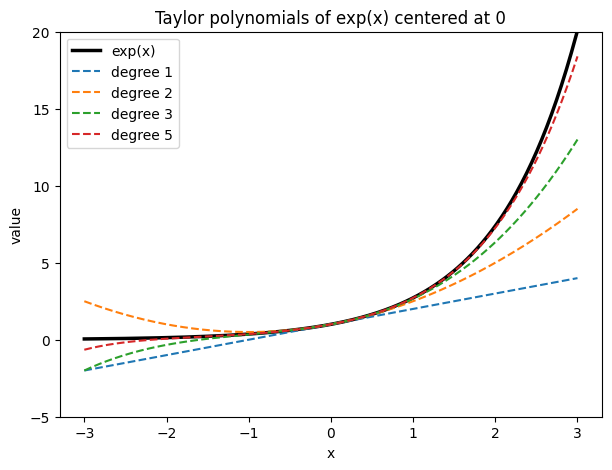

In [19]:
from math import factorial

def taylor_exp(x, n):
    return sum(x**k / factorial(k) for k in range(n + 1))

x = np.linspace(-3, 3, 400)
degrees = [1, 2, 3, 5]

plt.figure(figsize=(7, 5))
plt.plot(x, np.exp(x), "k", linewidth=2.5, label="exp(x)")
for n in degrees:
    plt.plot(x, taylor_exp(x, n), "--", label=f"degree {n}")
plt.ylim(-5, 20)
plt.xlabel("x"); plt.ylabel("value")
plt.title("Taylor polynomials of exp(x) centered at 0")
plt.legend()
plt.show()

Each additional term makes the polynomial closer to $e^x$ over wider interval around 0, so the larger $|x|$ gets, the more the approximations separate from the curve.

Below checks this numerically and tests the remainder bound.

  n    max error on [-1,1]     error at x=2     bound at x=2
  1              7.183e-01        4.389e+00        1.478e+01
  2              2.183e-01        2.389e+00        9.852e+00
  3              5.162e-02        1.056e+00        4.926e+00
  4              9.948e-03        3.891e-01        1.970e+00
  5              1.615e-03        1.224e-01        6.568e-01
  6              2.263e-04        3.350e-02        1.877e-01
  8              3.059e-06        1.755e-03        1.043e-02

Checks passed: the actual error never exceeds the Lagrange remainder bound.


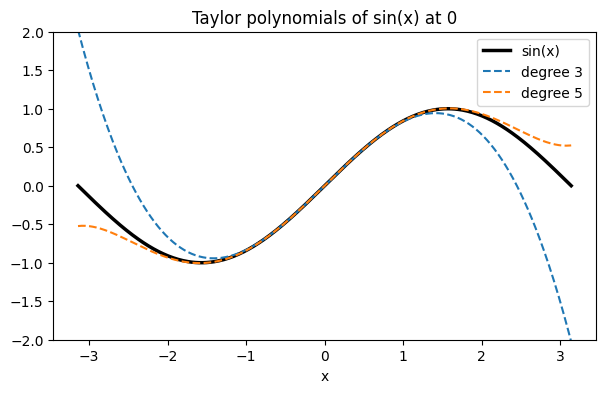

Max error of degree-5 polynomial on [-1, 1]: 0.0001956212297087312


In [20]:
print(f"{'n':>3} {'max error on [-1,1]':>22} {'error at x=2':>16} {'bound at x=2':>16}")
for n in [1, 2, 3, 4, 5, 6, 8]:
    xs = np.linspace(-1, 1, 1001)
    max_err = np.max(np.abs(np.exp(xs) - taylor_exp(xs, n)))
    err2 = abs(np.exp(2.0) - taylor_exp(2.0, n))
    bound2 = np.exp(2.0) * 2.0**(n + 1) / factorial(n + 1)
    assert err2 <= bound2 + 1e-12, "Lagrange bound violated!"
    print(f"{n:>3} {max_err:22.3e} {err2:16.3e} {bound2:16.3e}")
print("\nChecks passed: the actual error never exceeds the Lagrange remainder bound.")

# Second example (my own): sin(x) near 0, degree 3 and 5
xs = np.linspace(-np.pi, np.pi, 400)
T3 = xs - xs**3 / 6
T5 = xs - xs**3 / 6 + xs**5 / 120
plt.figure(figsize=(7, 4))
plt.plot(xs, np.sin(xs), "k", linewidth=2.5, label="sin(x)")
plt.plot(xs, T3, "--", label="degree 3")
plt.plot(xs, T5, "--", label="degree 5")
plt.ylim(-2, 2)
plt.title("Taylor polynomials of sin(x) at 0")
plt.xlabel("x"); plt.legend()
plt.show()
print("Max error of degree-5 polynomial on [-1, 1]:",
      np.max(np.abs(np.sin(xs[np.abs(xs) <= 1]) - T5[np.abs(xs) <= 1])))

The max error within the bounds $[-1,1]$ drops with each added degree because the remainder contains the factor $1/(n+1)!$. The bound at $x=2$ is larger than $x=1$ since $|x|^{n+1}$ grows more the further it is from the center, which matches the plot.

This shows that Taylor polynomials are best nearest to the expansion point.

---